In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from joblib import dump, load
from sklearn.model_selection import train_test_split
import numpy as np

In [1]:
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

In [9]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [10]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.139549,0.139549,0.074628,0.076809,0.110355,0.109143,-0.104943,-0.104949,0.101123,0.101123,...,-0.104944,-0.104944,0.048839,0.048807,-0.104665,-0.104944,-0.107797,-0.107797,open,alzeimer
1,0.111165,0.111165,-0.114587,0.141499,0.140278,-0.111531,-0.114618,-0.114587,0.027081,0.026739,...,-0.114587,-0.114587,0.017284,0.110226,0.096860,-0.114577,0.064786,0.064786,open,healthy
2,-0.101214,0.026066,0.067344,0.089492,0.133332,0.123303,0.026007,-0.104496,0.119220,0.119882,...,-0.104230,-0.104517,0.116153,0.116152,-0.104203,-0.104622,-0.104624,-0.104514,closed,alzeimer
3,0.137175,0.137182,-0.104280,-0.075285,0.117270,0.124822,-0.102878,-0.102878,-0.102729,0.070715,...,-0.102878,-0.126914,-0.123184,0.096253,0.097829,-0.102850,0.045935,0.045934,closed,healthy
4,0.070571,0.070571,-0.084270,0.166135,0.187948,0.078796,-0.084270,-0.084270,-0.142347,0.025127,...,-0.084263,-0.136264,-0.159768,0.002975,0.022801,-0.080528,0.098315,0.099038,open,healthy


In [11]:
train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       64 non-null     float64
 1   1       64 non-null     float64
 2   2       64 non-null     float64
 3   3       64 non-null     float64
 4   4       64 non-null     float64
 5   5       64 non-null     float64
 6   6       64 non-null     float64
 7   7       64 non-null     float64
 8   8       64 non-null     float64
 9   9       64 non-null     float64
 10  10      64 non-null     float64
 11  11      64 non-null     float64
 12  12      64 non-null     float64
 13  13      64 non-null     float64
 14  14      64 non-null     float64
 15  15      64 non-null     float64
 16  16      64 non-null     float64
 17  17      64 non-null     float64
 18  18      64 non-null     float64
 19  19      64 non-null     object 
 20  20      64 non-null     object 
dtypes: float64(19), object(2)
memory usage: 1

In [12]:
test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       32 non-null     float64
 1   1       32 non-null     float64
 2   2       32 non-null     float64
 3   3       32 non-null     float64
 4   4       32 non-null     float64
 5   5       32 non-null     float64
 6   6       32 non-null     float64
 7   7       32 non-null     float64
 8   8       32 non-null     float64
 9   9       32 non-null     float64
 10  10      32 non-null     float64
 11  11      32 non-null     float64
 12  12      32 non-null     float64
 13  13      32 non-null     float64
 14  14      32 non-null     float64
 15  15      32 non-null     float64
 16  16      32 non-null     float64
 17  17      32 non-null     float64
 18  18      32 non-null     float64
 19  19      32 non-null     object 
 20  20      32 non-null     object 
dtypes: float64(19), object(2)
memory usage: 5

In [13]:
train.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000
mean,0.036004,0.048890,-0.060384,0.039612,0.118018,0.065465,-0.083777,-0.077995,-0.012765,0.058388,0.003883,-0.093859,-0.056940,-0.009265,0.034821,0.012880,-0.061622,0.016351,0.022295
std,0.094167,0.098546,0.077925,0.109979,0.038263,0.084572,0.059460,0.055035,0.090204,0.071345,0.103794,0.045696,0.081771,0.107222,0.096715,0.102347,0.071298,0.097298,0.100511
min,-0.124406,-0.180989,-0.202975,-0.241650,-0.042187,-0.111531,-0.175719,-0.140547,-0.149036,-0.198359,-0.194228,-0.206614,-0.184353,-0.234128,-0.146009,-0.218617,-0.152409,-0.176093,-0.171735
25%,-0.047744,-0.007632,-0.106516,-0.078158,0.111488,-0.019475,-0.106886,-0.105854,-0.098477,0.038116,-0.100469,-0.108089,-0.105438,-0.095705,-0.069217,-0.095079,-0.105382,-0.088277,-0.084941
50%,0.068653,0.091945,-0.092826,0.088894,0.132272,0.098764,-0.099290,-0.098388,-0.029779,0.070886,0.032757,-0.101369,-0.091165,-0.047868,0.057481,0.041143,-0.094270,0.042389,0.049198
75%,0.118864,0.121113,-0.042666,0.124397,0.133770,0.133141,-0.082853,-0.076716,0.078153,0.101240,0.081303,-0.087068,-0.043349,0.092656,0.110417,0.098080,-0.044910,0.105298,0.109376
max,0.181066,0.181066,0.123746,0.173647,0.187948,0.181182,0.143406,0.137923,0.131556,0.207854,0.207885,0.105819,0.154290,0.231951,0.224525,0.192187,0.111358,0.141145,0.156292


In [14]:
test.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,0.018275,-0.002441,-0.042538,0.033453,0.112815,0.056256,-0.068522,-0.081696,-0.022392,0.033285,0.008926,-0.077969,-0.061116,-0.008321,0.049598,0.055063,-0.064683,0.022059,0.039947
std,0.095581,0.114092,0.097689,0.104667,0.042354,0.090171,0.072206,0.055371,0.094287,0.090144,0.105857,0.055225,0.092466,0.084272,0.094770,0.098149,0.071338,0.101232,0.096417
min,-0.167993,-0.192187,-0.152655,-0.128340,0.000812,-0.118637,-0.164090,-0.173950,-0.175646,-0.155229,-0.206125,-0.137406,-0.179812,-0.162224,-0.133257,-0.191557,-0.200142,-0.174634,-0.114598
25%,-0.060099,-0.107509,-0.107171,-0.078731,0.094273,-0.001594,-0.111670,-0.110956,-0.099595,-0.007001,-0.081946,-0.109006,-0.116077,-0.076842,-0.038759,-0.022686,-0.110347,-0.073451,-0.057267
50%,0.026259,0.025019,-0.087924,0.055416,0.132361,0.081061,-0.099421,-0.098496,-0.055965,0.051759,0.045539,-0.093172,-0.102538,-0.027010,0.086448,0.096547,-0.097236,0.058854,0.078261
75%,0.111269,0.111265,0.031641,0.130633,0.133768,0.133299,-0.032268,-0.070127,0.051371,0.104505,0.106413,-0.073747,-0.028704,0.055924,0.118455,0.128722,-0.033835,0.116564,0.118399
max,0.162890,0.162890,0.192873,0.190485,0.206569,0.206115,0.122086,0.090437,0.169604,0.151054,0.151291,0.136298,0.151212,0.137423,0.171256,0.165999,0.103279,0.162936,0.187712


In [15]:
print(train.isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
dtype: int64


In [16]:
print(test.isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
dtype: int64


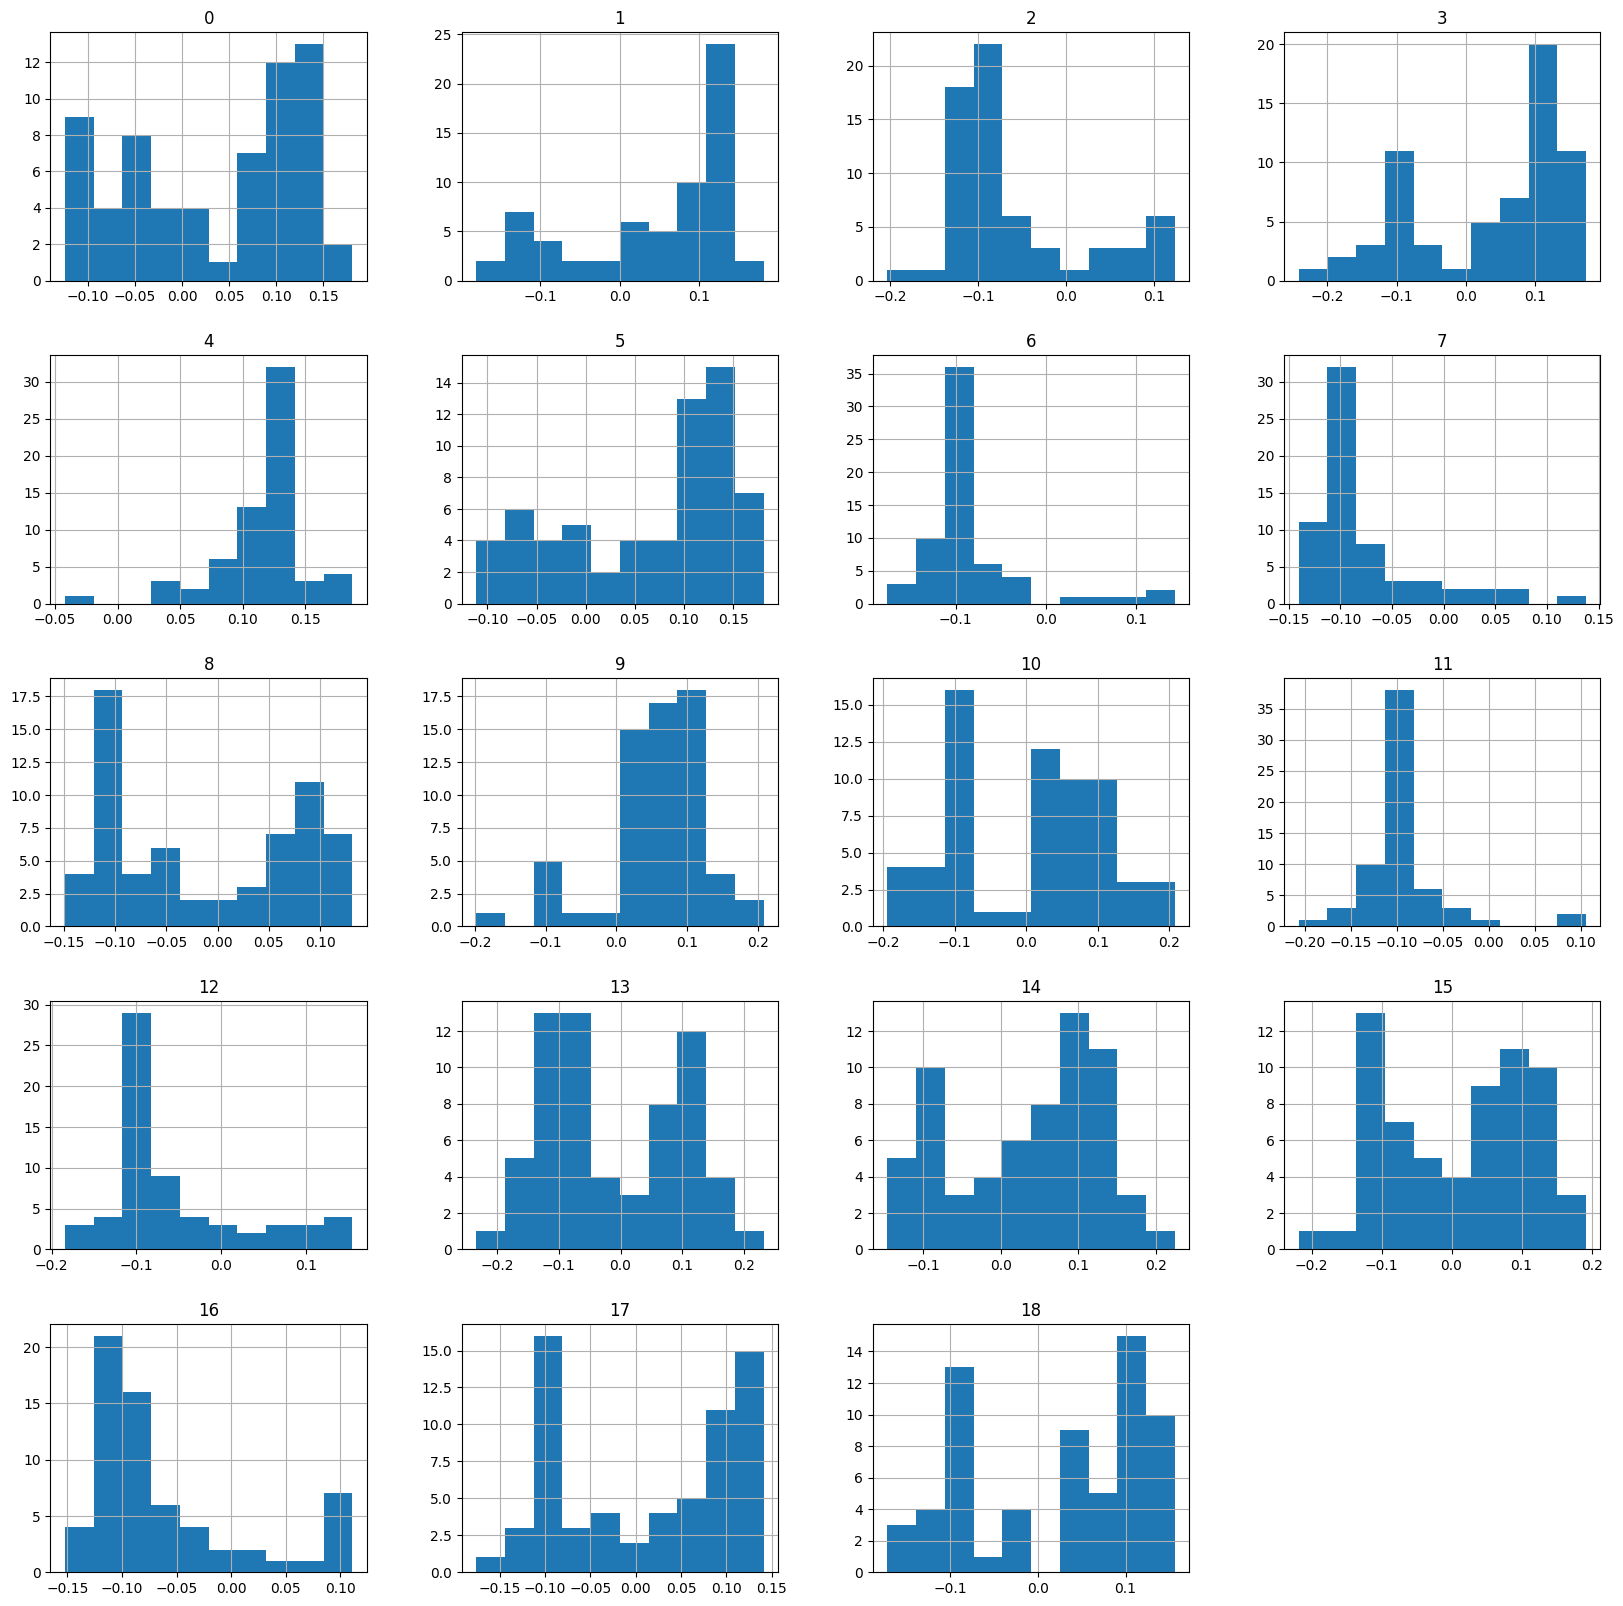

In [17]:
p = train.hist(figsize = (20,20))

ENCODING THE DATA

In [18]:
def encode(df) :
    df = pd.get_dummies(df,drop_first = True)
    df['alz_true'] =  1 - df['20_healthy']
    del df['20_healthy']
    return df

In [19]:
train = encode(train)

In [20]:
test = encode(test)

In [21]:
train

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19_open,alz_true
0,0.139549,0.139549,0.074628,0.076809,0.110355,0.109143,-0.104943,-0.104949,0.101123,0.101123,...,-0.104944,-0.104944,0.048839,0.048807,-0.104665,-0.104944,-0.107797,-0.107797,True,1
1,0.111165,0.111165,-0.114587,0.141499,0.140278,-0.111531,-0.114618,-0.114587,0.027081,0.026739,...,-0.114587,-0.114587,0.017284,0.110226,0.096860,-0.114577,0.064786,0.064786,True,0
2,-0.101214,0.026066,0.067344,0.089492,0.133332,0.123303,0.026007,-0.104496,0.119220,0.119882,...,-0.104230,-0.104517,0.116153,0.116152,-0.104203,-0.104622,-0.104624,-0.104514,False,1
3,0.137175,0.137182,-0.104280,-0.075285,0.117270,0.124822,-0.102878,-0.102878,-0.102729,0.070715,...,-0.102878,-0.126914,-0.123184,0.096253,0.097829,-0.102850,0.045935,0.045934,False,0
4,0.070571,0.070571,-0.084270,0.166135,0.187948,0.078796,-0.084270,-0.084270,-0.142347,0.025127,...,-0.084263,-0.136264,-0.159768,0.002975,0.022801,-0.080528,0.098315,0.099038,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.118834,0.118834,0.048483,0.052575,0.133722,0.132642,-0.105768,-0.105811,0.097860,0.097858,...,-0.105726,-0.105736,0.075445,0.075427,-0.105691,-0.105728,-0.105752,-0.105747,True,1
60,0.105533,0.105533,-0.052484,0.105989,0.141491,0.120746,-0.168287,-0.089074,0.022302,0.025173,...,-0.093383,-0.071637,-0.044488,0.131796,0.141265,-0.082713,-0.081779,-0.078486,False,1
61,-0.052887,0.015069,-0.044170,-0.104695,0.133587,0.138173,-0.091927,0.043029,0.094451,0.095946,...,-0.050237,-0.079758,0.116682,0.116684,0.140545,-0.052181,-0.105035,-0.157981,False,1
62,-0.054503,-0.115595,-0.083362,0.133363,0.133692,0.010891,-0.160208,-0.140547,0.117174,0.117156,...,-0.078588,0.021055,0.093122,0.098347,0.082086,-0.033107,0.066865,-0.171735,False,1


In [22]:
test

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19_open,alz_true
0,-0.001124,-0.138938,0.053684,0.149959,0.132458,-0.023014,-0.029251,-0.154850,0.063198,-0.070156,...,0.002004,0.151212,-0.040217,-0.045485,-0.191557,0.037668,-0.049613,0.187712,False,1
1,0.026159,-0.126278,0.028168,-0.055391,0.133766,0.133832,-0.129934,0.061052,-0.059560,-0.033421,...,0.136298,-0.105312,-0.074711,0.127730,0.140486,0.026925,0.030795,-0.054477,False,1
2,-0.033497,-0.174204,-0.081404,0.117564,0.133623,0.126433,0.088825,-0.055921,-0.115973,0.034569,...,-0.117561,0.098882,-0.162224,-0.092885,-0.018426,-0.024845,0.116494,0.116489,True,1
3,0.047896,0.047898,-0.108099,-0.063487,0.069918,0.083256,-0.108122,-0.108122,-0.107395,0.069964,...,-0.108122,-0.108122,-0.108015,0.165962,0.165999,0.103279,-0.108118,0.103278,False,0
4,0.135847,0.135847,-0.107834,-0.086533,0.115513,0.121880,-0.107022,-0.107023,-0.107051,0.072755,...,-0.107023,-0.110284,-0.109067,0.098469,0.098872,-0.107018,0.048455,0.048455,False,0
5,0.023677,0.023677,-0.116857,-0.079987,0.095517,0.102842,-0.116857,-0.116857,-0.107624,0.100910,...,-0.116857,-0.116792,-0.019159,0.146063,0.158003,-0.116488,0.076010,0.075974,True,0
6,-0.014452,-0.114027,0.143011,-0.100051,0.133771,0.133801,-0.032577,-0.068303,-0.085481,-0.049549,...,0.020441,-0.154515,0.035750,-0.006905,-0.035464,0.084717,-0.174634,0.146123,True,1
7,0.110820,0.110820,-0.112688,0.140892,0.139740,-0.109772,-0.112700,-0.112688,0.039892,0.039743,...,-0.112689,-0.112690,-0.030095,0.106673,0.109695,-0.112686,0.063973,0.063973,True,0
8,-0.102440,-0.102595,-0.102373,0.090544,0.090542,-0.102372,-0.102372,-0.102468,0.052899,0.053620,...,-0.102372,-0.120298,0.021707,0.102915,0.148441,0.098354,0.133336,0.147301,True,0
9,-0.106860,-0.106579,-0.103965,-0.101841,0.077757,0.078867,-0.103965,-0.103965,0.050862,0.075528,...,-0.103965,-0.102639,0.077510,0.171256,0.162474,-0.104421,0.084267,0.084266,True,0


In [23]:
X_train,y_train = train[train.columns[:-1]].values , train[train.columns[-1]].values
X_test,y_test = test[test.columns[:-1]].values, test[test.columns[-1]].values

In [24]:
print(X_train.shape, y_train.shape)

(64, 20) (64,)


In [25]:
print(X_test.shape, y_test.shape)

(32, 20) (32,)


# LINEAR MODELS

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
Accuracy_LR = logreg.score(X_test, y_test)
print(Accuracy_LR*100)

81.25


# NORMAL NON-LINEAR MODELS

In [29]:
from sklearn import svm

In [30]:
clf = svm.SVC()
clf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
Accuracy_SVM = clf.score(X_test, y_test)
print(Accuracy_SVM*100)

84.375


In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
Accuracy_KNN = knn.score(X_test, y_test)
print(Accuracy_KNN*100)

71.875


<BarContainer object of 2 artists>

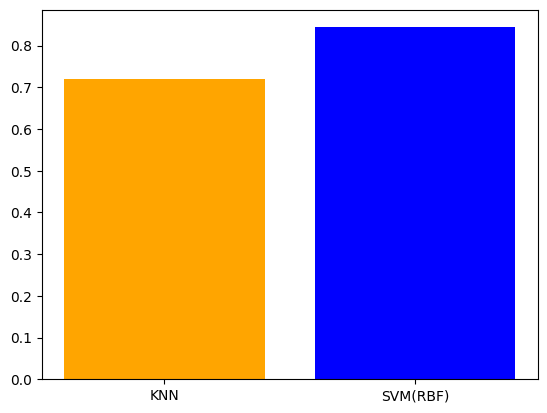

In [35]:
plt.bar(['KNN','SVM(RBF)'],[Accuracy_KNN,Accuracy_SVM],color = ['orange','blue'])

#TREE MODELS

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
Accuracy_DT = dt.score(X_test, y_test)
print(Accuracy_DT*100)

84.375


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
Accuracy_RF = rf.score(X_test, y_test)
print(Accuracy_RF*100)

84.375


<BarContainer object of 2 artists>

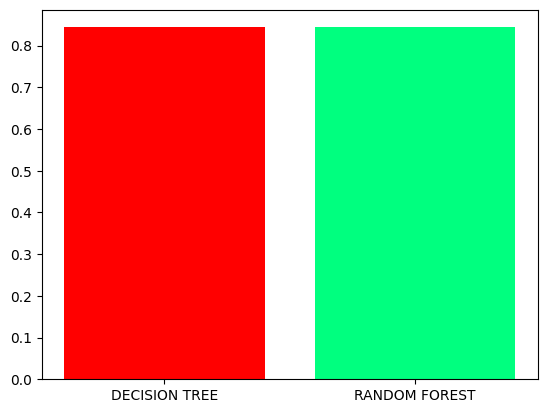

In [42]:
plt.bar(['DECISION TREE','RANDOM FOREST'],[Accuracy_DT,Accuracy_RF],color = ['red','springgreen'])

# PROBABLITY BASED MODELS

In [43]:
from sklearn.naive_bayes import GaussianNB

In [44]:
gaus = GaussianNB()
gaus.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [45]:
Accuracy_GAUS = gaus.score(X_test, y_test)
print(Accuracy_GAUS*100)

100.0


In [46]:
from sklearn.naive_bayes import BernoulliNB

In [47]:
bern = BernoulliNB()
bern.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [48]:
Accuracy_BERN = bern.score(X_test, y_test)
print(Accuracy_BERN*100)

90.625


<BarContainer object of 2 artists>

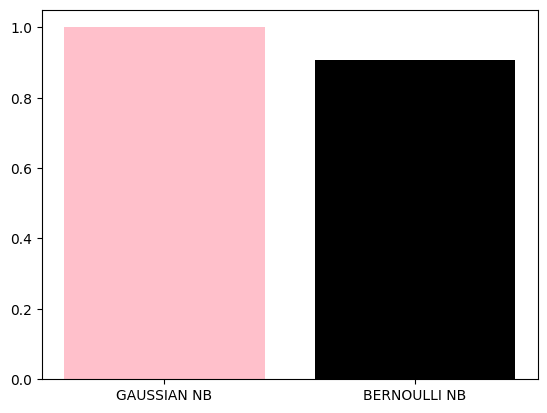

In [49]:
plt.bar(['GAUSSIAN NB','BERNOULLI NB'],[Accuracy_GAUS,Accuracy_BERN],color = ['pink','black'])

**Based on the above results and taking into account the low sample size of the dataset,its important to train and test these models on different sets of training and testing sets to understand the generalization ability of our model**.
# COMPARISON OF VARIOUS ML MODELS ON DIFFERENT SET OF DATA


*   Our comparison technique starts by splitting a whole dataset into train/   test in 15 random ways using sklearn parameter "random_state".
*   In our next step fit the best model from groups (Non-linear,Tree since they are much better) on these 15 different datasets and note down the model's score on the randomly created on every test set.

*   Next we plot the results to find which model has the highest accuracy and at which "random_state" did we obtain it.


*   Then we take the models and fit by the best "random_state" to build a combined classifier to combine all the best models as our finalized model.



*   The best "random_state" can be obtained by finding which "random_state" produces most accuracy for the model.









i) Defining Functions for comparison

In [50]:
X = np.concatenate([X_train,X_test])
y = np.concatenate([y_train,y_test])

In [51]:
color = ['blue','springgreen','yellow']

In [52]:
import random as Random
rands = [Random.randint(1,300) for i in range(0,15)]
def fit_and_score(model):
    scores = []
    states = []
    for i in range(15):
        state = rands[i]
        X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.3,random_state=state)
        model.fit(X_train,y_train)
        scores.append(model.score(X_test,y_test)*100)
        states.append(state)
    return scores,states    

In [53]:
models = [clf,knn,rf] # Best models & will discard NB models & Logistic since they produce low perfromance score
model_names = ["SupportVectorMachine","KNearestNeighour","RandomForest"]  
plot_scores = []
r_states = []

for model in models:
    scores,states = fit_and_score(model)
    plot_scores.append(scores)
    r_states.append(states)

ii) Plotting of all Models Performances on Different data

Model :  SupportVectorMachine  ->  Best State :  24
Model :  KNearestNeighour  ->  Best State :  81
Model :  RandomForest  ->  Best State :  138


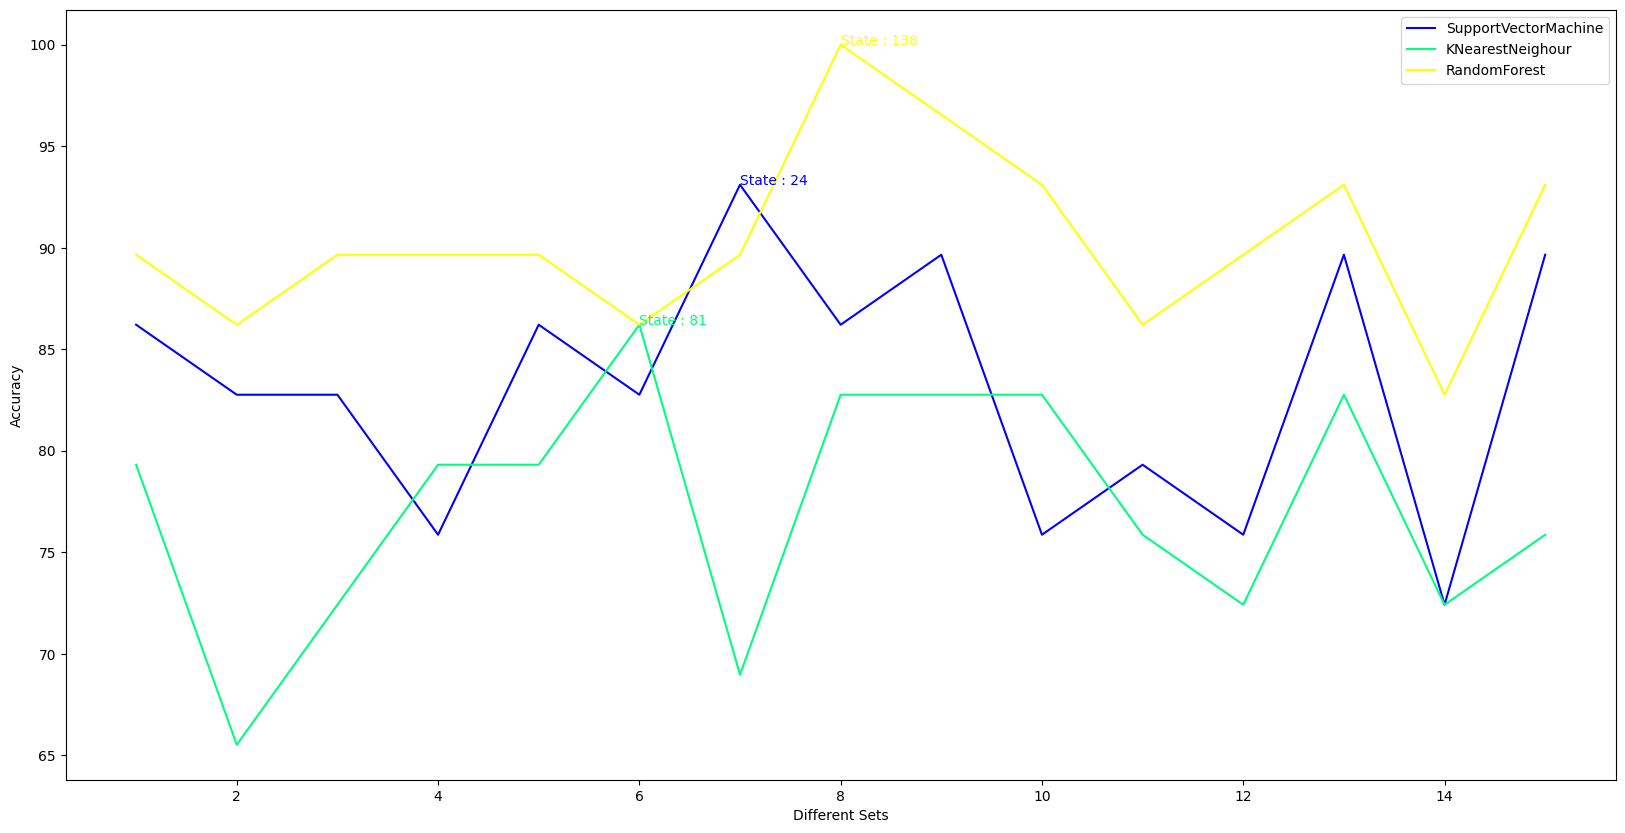

In [54]:
f = plt.figure()
f.set_figwidth(20)
f.set_figheight(10)

for i in range(0,3):
    plt.plot([s for s in range(1,16)],plot_scores[i],label = model_names[i],color = color[i])
    plt.legend()
    max_ind = plot_scores[i].index(max(plot_scores[i])) 
    max_state = r_states[i][max_ind]
    print("Model : ",model_names[i]," ->  Best State : ",max_state)
    plt.text(max_ind+1,plot_scores[i][max_ind],str("State : " + str(max_state)),size = 10,color = color[i])

plt.xlabel("Different Sets")
plt.ylabel("Accuracy")
plt.show()    


# Buidling a combined classifier

The reason to train a combined classifier is to increase a generalization of the output so that each model from the above best models can produce its own output based on what it has learnt apart from other models and combine those outputs to provide a more assured answer.During testing we predict test cases on these best models and use majority voting to produce the final output.

**(i) Training Phase**

In [55]:
models = [svm.SVC(),
          KNeighborsClassifier(n_neighbors = 3),
          RandomForestClassifier()]

model_names = ["SVM","KNN","RFC"]
best_r_states = [105,105,105]
def state_scores(model,name,state):  
    X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.3,random_state=state)
    # Adding Noise to improve as a response to small dataset
    model.fit(X_train + np.random.normal(size = X_train.shape,loc = 0,scale = 0.01), y_train)
    name = name + ".joblib"
    dump(model,name)
    return model.score(X_test,y_test)*100
scores = []
for i in range(len(models)):
    print("Model Name : ",model_names[i])
    score = state_scores(models[i],model_names[i],best_r_states[i])
    scores.append(score)
    print("Score : ",score)    

Model Name :  SVM
Score :  72.41379310344827
Model Name :  KNN
Score :  75.86206896551724
Model Name :  RFC
Score :  86.20689655172413


<BarContainer object of 3 artists>

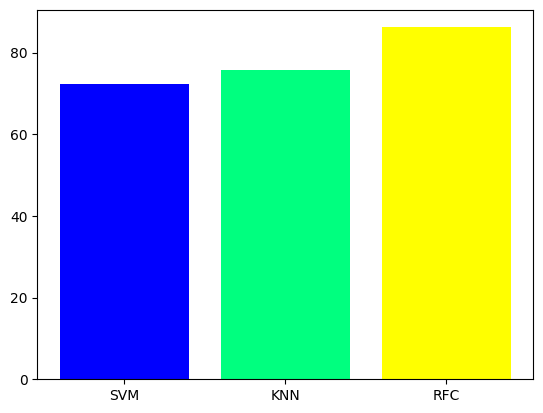

In [56]:
plt.bar(model_names,scores,color = color)

**(i) Testing Phase**

In [59]:
def combined_classifier():
    knn = load("KNN.joblib")
    svvc = load("SVM.joblib")
    rfc = load("RFC.joblib")
    return (svvc,knn,rfc)

models = combined_classifier()

def predict(test):
    result1 = models[0].predict(test)
    result2 = models[1].predict(test)
    result3 = models[2].predict(test)
    results = np.array([result1,result2,result3]).T.tolist()
    results = [Counter(res).most_common(1)[0][0] for res in results]
    return np.array(results)

**Calling the combined classifier "predict"**

In [60]:
preds = predict(X_test)

# Performance Metrics 

In [61]:
from sklearn.metrics import *

In [62]:
f1_score(preds,y_test)*100

90.9090909090909

In [63]:
precision_score(preds,y_test)*100

93.75

In [64]:
accuracy_score(preds,y_test)*100

90.625

In [65]:
tn, fp, fn, tp = confusion_matrix(preds,y_test).ravel()
print("TP : ",tp)
print("FP : ",fp)
print("TN : ",tn)
print("FN : ",fn)

TP :  15
FP :  1
TN :  14
FN :  2
